### Class Exercise: Descriptive Statistics (5 points)

Using the `df` DataFrame above, answer the following:

- Get the summary statistics for the `quantity_sold` column using `.describe()`
  
- What is the average `quantity_sold`?
  
- What is the maximum `price_thb`?
  
- Is there a strong correlation between `price_thb` and `quantity_sold`? What does that tell you? (1+1 points)

In [ ]:
#Get the summary statistics for the `quantity_sold` column using `.describe()`
df['quantity_sold'].describe()

count     15.000000
mean      87.333333
std       45.625285
min       30.000000
25%       57.500000
50%       85.000000
75%      105.000000
max      200.000000
Name: quantity_sold, dtype: float64

In [ ]:
#What is the average `quantity_sold`?
df['quantity_sold'].mean()


np.float64(87.33333333333333)

In [ ]:
#What is the maximum `price_thb`?
df['price_thb'].max()

np.int64(180)

In [ ]:
#Is there a strong correlation between `price_thb` and `quantity_sold`? What does that tell you?
df.corr(numeric_only=True)

,price_thb,quantity_sold
price_thb,1.000000,-0.598457
quantity_sold,-0.598457,1.000000


### Class Exercise: Selecting and Filtering

Using the `df_indexed` DataFrame (fruit as index), answer the following:

- Select the row for `'Cherry'` using `.loc`
  
- Select the row at position 5 using `.iloc`
  
- Filter `df` to show only fruits with `quantity_sold` greater than 100
  
- Filter `df` to show fruits priced under 50 THB **and** sold more than 80 times
  

In [ ]:
#Select the row for `'Cherry'` using `.loc`
df_indexed.loc['Cherry']

price_thb        180
quantity_sold     30
Name: Cherry, dtype: int64

In [ ]:
#Select the row at position 5 using `.iloc`
df_indexed.iloc[5]

price_thb        45
quantity_sold    40
Name: Pineapple, dtype: int64

In [ ]:
#Filter `df` to show only fruits with `quantity_sold` greater than 100
df[df['quantity_sold'] > 100]

,fruit,price_thb,quantity_sold
0,Apple,55,120
1,Banana,15,200
4,Orange,35,150
11,Peach,80,110


In [ ]:
#Filter `df` to show fruits priced under 50 THB **and** sold more than 80 times
df[(df['price_thb'] < 50) & (df['quantity_sold'] > 80)]

,fruit,price_thb,quantity_sold
1,Banana,15,200
2,Mango,40,90
4,Orange,35,150
9,Papaya,30,100


### Class Exercise: Handling Missing Data

- Check how many missing values exist in each column of `df_missing`
  
- Instead of dropping rows, try filling the missing `price_thb` values with the column's mean (**HINT:** use `.fillna()`)
  
- Check again if any missing values remain in price_thb column

In [ ]:
#Check how many missing values exist in each column of `df_missing`

# YOUR CODE HERE
df_missing.isnull().sum()

fruit            0
price_thb        2
quantity_sold    1
dtype: int64

In [ ]:
#Make a copy of the dataframe

df_filled = df_missing.copy()

In [ ]:
#Check the mean of "price_thb" in df_filled
#Hint use .mean()

mean = df_filled['price_thb'].mean()

In [ ]:
#Fill the missing `price_thb` values with the column's mean (HINT: use `.fillna()`)

df_filled['price_thb'] = df_filled['price_thb'].fillna(mean)

In [ ]:
df_filled.isnull().sum()

fruit            0
price_thb        0
quantity_sold    1
dtype: int64

### Class Exercise: Initial Data Exploration

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

- What is the shape of each DataFrame?
  
- What are the column names in `movies`?
  
- What is the data type of the `age` column in `users`?
  
- Show the last 5 rows of `ratings`
  
- How many unique users are in `users`? (**HINT:** use `.nunique()`)
  
- How many unique movies are in `movies`?
  

In [ ]:
#What is the shape of each DataFrame?

# YOUR CODE HERE
users.shape, movies.shape, ratings.shape


((943, 5), (1682, 24), (100000, 4))

In [ ]:
#What are the column names in movies?

# YOUR CODE HERE
movies.columns


Index(['movie_id', 'movie_title', 'release_date', 'video_release_date',
       'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation', 'Childrens',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')

In [ ]:
#What is the data type of the age column in users?

# YOUR CODE HERE
users['age'].dtype


dtype('int64')

In [ ]:
#Show the last 5 rows of ratings

# YOUR CODE HERE
ratings.tail()


,user_id,movie_id,rating,timestamp
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156
99999,12,203,3,879959583


In [ ]:
#How many unique users are in users? (HINT: use .nunique())

# YOUR CODE HERE
users['user_id'].nunique()

943

In [ ]:
#How many unique movies are in movies?

# YOUR CODE HERE
movies['movie_id'].nunique()


1682

### Class Exercise: Data Cleaning

- Check if there are any duplicate rows in `users`, `movies`, and `ratings` (**HINT:** use `.duplicated().sum()`)
  
- If any duplicates exist, drop them (**HINT:** use `.drop_duplicates()`)
  
- Verify the new shape of each DataFrame after dropping duplicates

In [ ]:
# YOUR CODE HERE

In [ ]:
users.duplicated().sum()

np.int64(0)

In [ ]:
movies.duplicated().sum()

np.int64(0)

In [ ]:
ratings.duplicated().sum()

np.int64(0)

In [ ]:
users = users.drop_duplicates()
movies = movies.drop_duplicates()
ratings = ratings.drop_duplicates()

### Class Exercise: Data Visualization

- Draw a histogram of the `age` column in `users`
  
- Count how many users belong to each `occupation`, and plot it as a bar chart (**HINT:** use `.value_counts()`)

array([[<Axes: title={'center': 'age'}>]], dtype=object)

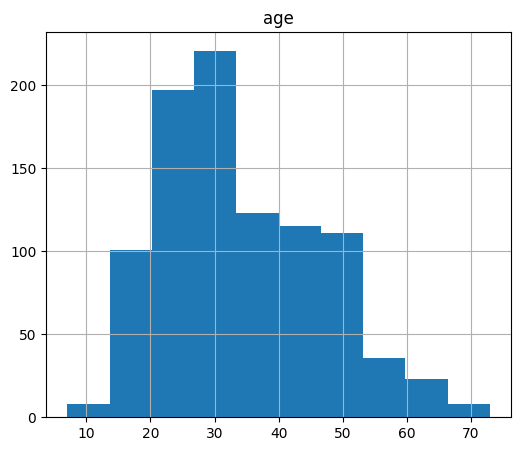

In [ ]:
#Draw a histogram of the `age` column in `users`

#YOUR_CODE_HERE
users.hist(column='age', figsize=(6, 5))

<Axes: title={'center': 'Number of Users per Occupation'}, xlabel='Occupation', ylabel='Number of Users'>

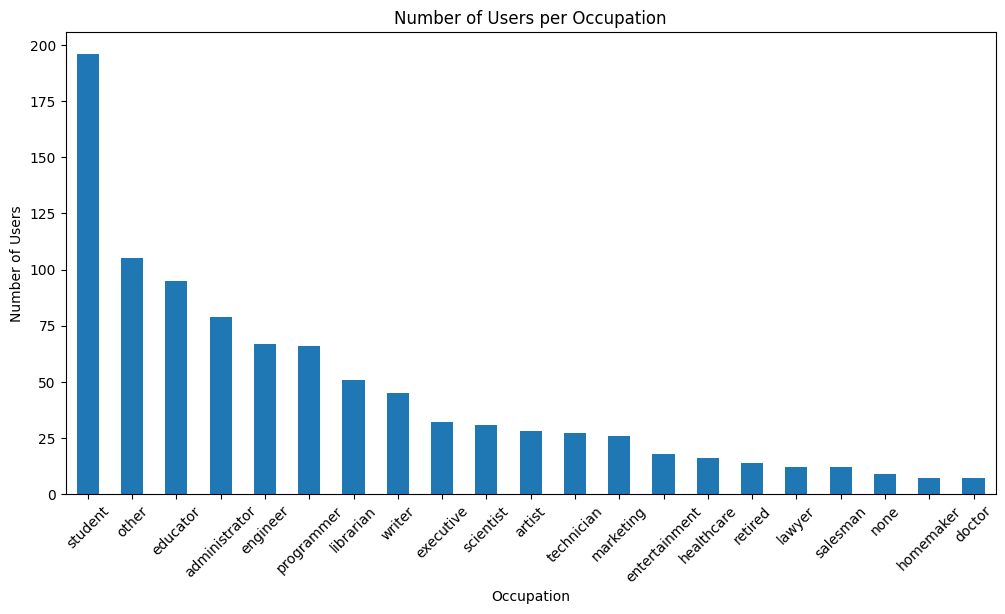

In [ ]:
#Count how many users belong to each `occupation`, and plot it as a bar chart (**HINT:** use `.value_counts()`)

#YOUR_CODE_HERE

occupation_counts = users['occupation'].value_counts()

occupation_counts.plot.bar(figsize=(12, 6), rot=45, xlabel='Occupation', ylabel='Number of Users',
                            title='Number of Users per Occupation')

### Class Exercise: Data Manipulation

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

- Filter `movies` to show only movies with `'Trek'` in the title
  
- Merge `ratings` and `movies` on `movie_id` using an inner join
  
- Using the merged DataFrame, find the average rating for each `movie_title` (**HINT:** use `.groupby()`
  
- Convert the `timestamp` column in `ratings` to a proper datetime column
  
- Extract the year from the converted date, and find the average rating given per year

In [ ]:
# YOUR CODE HERE

In [ ]:
# Filter movies with 'Trek' in the title
is_trek = movies['movie_title'].str.contains('Trek')
movies[is_trek]

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
221,222,Star Trek: First Contact (1996),22-Nov-1996,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
226,227,Star Trek VI: The Undiscovered Country (1991),01-Jan-1991,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
227,228,Star Trek: The Wrath of Khan (1982),01-Jan-1982,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
228,229,Star Trek III: The Search for Spock (1984),01-Jan-1984,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
229,230,Star Trek IV: The Voyage Home (1986),01-Jan-1986,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
379,380,Star Trek: Generations (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
448,449,Star Trek: The Motion Picture (1979),01-Jan-1979,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
449,450,Star Trek V: The Final Frontier (1989),01-Jan-1989,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
# Merge ratings and movies on movie_id
ratings_movies = pd.merge(ratings, movies, on='movie_id', how='inner')
ratings_movies.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year,movie_title,release_date,imdb_url,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,1997-12-04 15:55:49,1997,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,1998-04-04 19:22:22,1998,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,1997-11-07 07:18:36,1997,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,1997-11-27 05:02:03,1997,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,1998-02-02 05:33:16,1998,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Average rating for each movie_title
avg_rating_by_title = ratings_movies[['movie_title', 'rating']].groupby('movie_title').mean()
avg_rating_by_title.head()

,rating
movie_title,
'Til There Was You (1997),2.333333
1-900 (1994),2.600000
101 Dalmatians (1996),2.908257
12 Angry Men (1957),4.344000
187 (1997),3.024390


In [ ]:
# Convert timestamp to datetime
ratings['rating_date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year
0,196,242,3,881250949,1997-12-04 15:55:49,1997
1,186,302,3,891717742,1998-04-04 19:22:22,1998
2,22,377,1,878887116,1997-11-07 07:18:36,1997
3,244,51,2,880606923,1997-11-27 05:02:03,1997
4,166,346,1,886397596,1998-02-02 05:33:16,1998


In [ ]:
# Extract year and find average rating per year
ratings['rating_year'] = ratings['rating_date'].dt.year
ratings[['rating_year', 'rating']].groupby('rating_year').mean()

,rating
rating_year,
1997,3.56812
1998,3.48689


## Putting It All Together

Let's finish with a combined analysis question that uses everything we've covered, merging, grouping, filtering, and correlation.

### Capstone Exercise

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

**Question:** Are older users more generous with their ratings than younger users? Is there a relationship between a user's age and the rating they give?

- Merge `ratings` and `users` on `user_id`
  
- Find the correlation between `age` and `rating` (**HINT:** use `.corr()`)
  
- Group the merged data by `age`, and find the average rating per age
  
- Plot the average rating per age as a line chart

In [ ]:
# YOUR CODE HERE

In [ ]:
# Merge ratings and users on user_id
ratings_users = pd.merge(ratings, users, on='user_id', how='inner')
ratings_users.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year,age,gender,occupation,zipcode
0,196,242,3,881250949,1997-12-04 15:55:49,1997,49,M,writer,55105
1,186,302,3,891717742,1998-04-04 19:22:22,1998,39,F,executive,00000
2,22,377,1,878887116,1997-11-07 07:18:36,1997,25,M,writer,40206
3,244,51,2,880606923,1997-11-27 05:02:03,1997,28,M,technician,80525
4,166,346,1,886397596,1998-02-02 05:33:16,1998,47,M,educator,55113


In [ ]:
# Correlation between age and rating
ratings_users[['age', 'rating']].corr()

,age,rating
age,1.00000,0.05446
rating,0.05446,1.00000


In [ ]:
# Average rating per age
avg_rating_by_age = ratings_users[['age', 'rating']].groupby('age').mean()
avg_rating_by_age.head()

,rating
age,
7,3.767442
10,3.387097
11,2.925926
13,3.470825
14,3.375000


<Axes: title={'center': 'Average Rating by Age'}, xlabel='Age', ylabel='Average Rating'>

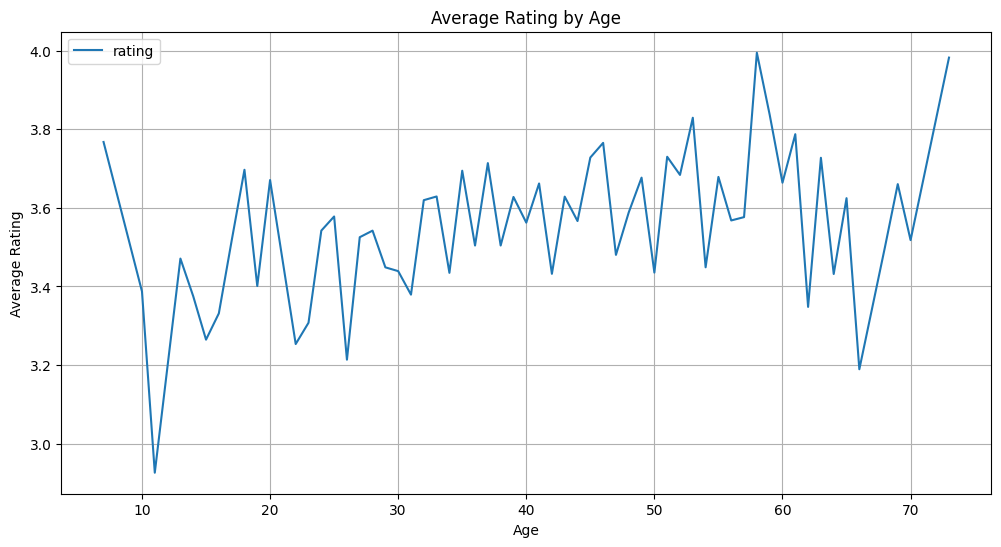

In [ ]:
# Plot average rating per age
avg_rating_by_age.plot(kind='line', y='rating', title='Average Rating by Age',
                        xlabel='Age', ylabel='Average Rating', figsize=(12, 6), grid=True)

The correlation value tells us how strong the relationship is:
- Close to **0** → very weak or no relationship between age and rating
- Positive value → older users tend to rate slightly higher
- Negative value → older users tend to rate slightly lower